In [6]:
import os

dataset_path = "../dataset/raw_dataset"

classes = os.listdir(dataset_path)

print("Classes found:")
for cls in classes:
    print("-", cls)

FileNotFoundError: [WinError 3] The system cannot find the path specified: '../dataset/raw_dataset'

In [8]:
import os

dataset_path = "../datasets/raw_dataset"

classes = os.listdir(dataset_path)

print("Classes found:")
for cls in classes:
    print("-", cls)

Classes found:
- Gothic
- Modern
- Mughal
- Neoclassical
- Pagodas
- Pyramids


In [7]:
import os

print(os.getcwd())

d:\Landmark-Recognition-Using-Deep-Learning\notebooks


In [10]:
import os

dataset_path = "../datasets/raw_dataset"

print("Image count per class:\n")

for cls in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, cls)

    if os.path.isdir(class_path):
        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])

        print(f"{cls}: {count} images")

Image count per class:

Gothic: 0 images
Modern: 0 images
Mughal: 0 images
Neoclassical: 0 images
Pagodas: 0 images
Pyramids: 0 images


In [11]:
import os

dataset_path = "../datasets/raw_dataset"

print("Image count per class:\n")

for cls in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, cls)

    if os.path.isdir(class_path):
        count = len([
            f for f in os.listdir(class_path)
            if f.lower().endswith(('.jpg', '.jpeg', '.png'))
        ])

        print(f"{cls}: {count} images")

Image count per class:

Gothic: 0 images
Modern: 0 images
Mughal: 0 images
Neoclassical: 0 images
Pagodas: 0 images
Pyramids: 0 images


In [12]:
import os

dataset_path = "../datasets/raw_dataset"

for cls in os.listdir(dataset_path):
    class_path = os.path.join(dataset_path, cls)

    if os.path.isdir(class_path):
        print(f"\n{cls}:")
        files = os.listdir(class_path)[:10]  # first 10 items
        print(files)


Gothic:
['ChartresCathedral', 'CologneCathedral', 'MilanCathedral', 'Notre-DameCathedral', 'St.VitusCathedral']

Modern:
['Cathedral of Bras�lia', 'CCTV Headquarters', 'Chrysler Building', 'eiffel', 'Hallgr�mskirkja']

Mughal:
['Bibi Ka Maqbara', 'Jama Masjid', 'Taj Mahal', 'Tomb of Akbar', 'Tomb of I_timad-ud-Daulah']

Neoclassical:
['Academy of Athens', 'Buckingham Palace', 'Concertgebouw', 'Panth�on', 'Ripon Building']

Pagodas:
['FogongTemplePagoda', 'GiantWildGoosePagoda', 'ShwedagonPagoda', 'ThienMuPagoda', 'TianningTemplePagoda']

Pyramids:
['El Castillo, Chichen Itza', 'Louvre Pyramid', 'Pyramid of Djoser', 'Pyramid of Giza', 'Santa Cecilia Acatitlan Pyramid']


In [13]:
import os

path = "../datasets/raw_dataset/Gothic/ChartresCathedral"

print(os.listdir(path)[:10])

['ChartresCathedral0.jpeg', 'ChartresCathedral12.jpeg', 'ChartresCathedral13.jpeg', 'ChartresCathedral15.jpeg', 'ChartresCathedral16.jpeg', 'ChartresCathedral17.jpeg', 'ChartresCathedral19.jpeg', 'ChartresCathedral2.jpeg', 'ChartresCathedral4.jpeg', 'ChartresCathedral5.jpeg']


In [15]:
import os

dataset_path = "../datasets/raw_dataset"

print("Image count by architecture style:\n")

for style in os.listdir(dataset_path):
    style_path = os.path.join(dataset_path, style)

    total_images = 0

    for landmark in os.listdir(style_path):
        landmark_path = os.path.join(style_path, landmark)

        if os.path.isdir(landmark_path):
            total_images += len([
                f for f in os.listdir(landmark_path)
                if f.lower().endswith((".jpg", ".jpeg", ".png"))
            ])

    print(f"{style}: {total_images} images")

Image count by architecture style:

Gothic: 70 images
Modern: 70 images
Mughal: 69 images
Neoclassical: 70 images
Pagodas: 70 images
Pyramids: 71 images


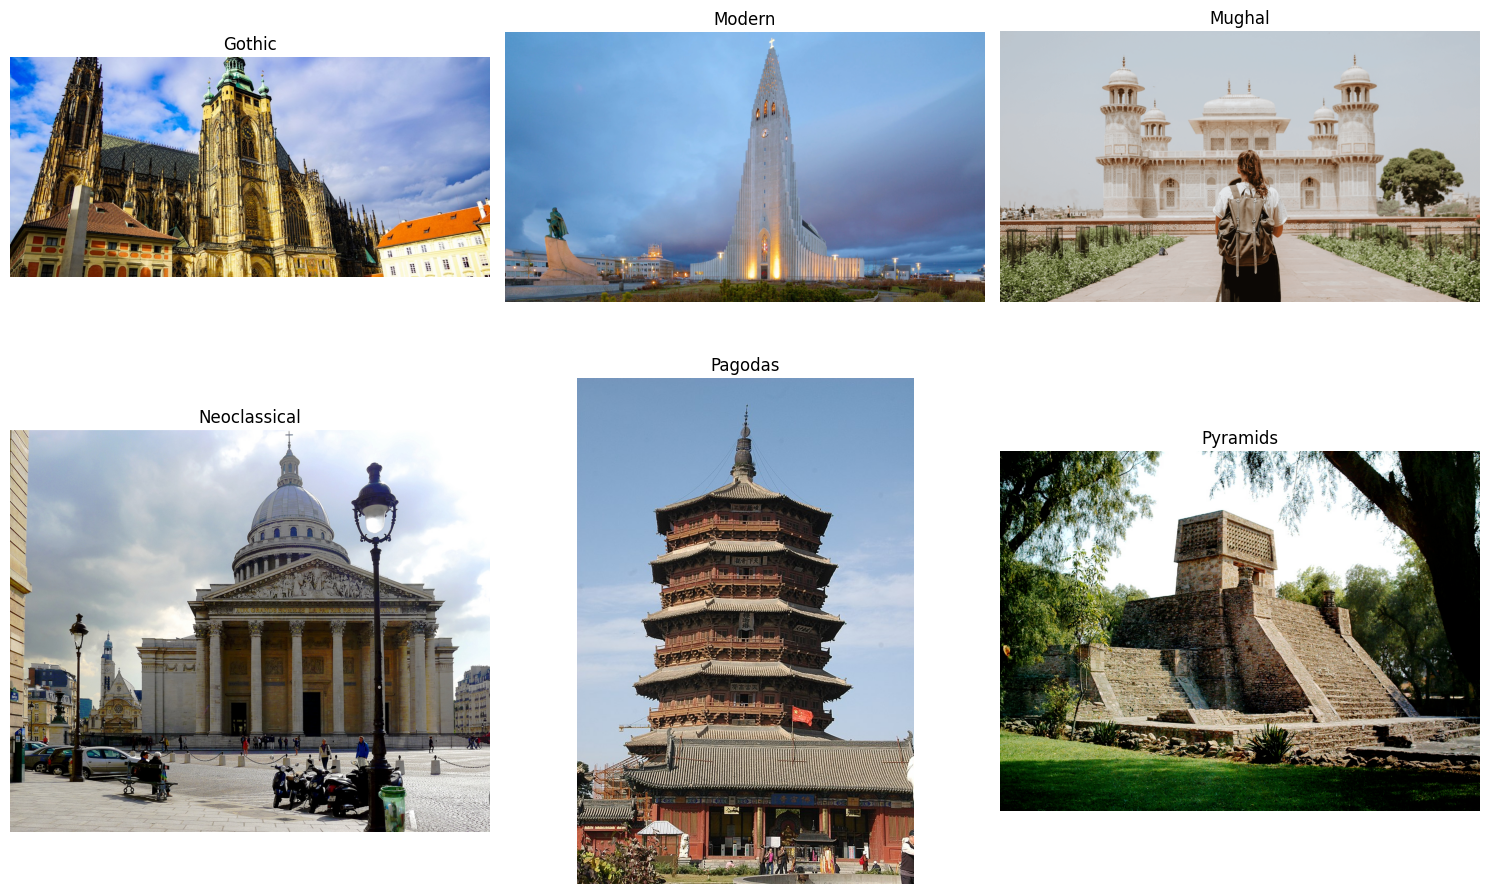

In [17]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image

dataset_path = "../datasets/raw_dataset"

plt.figure(figsize=(15, 10))

styles = os.listdir(dataset_path)

for i, style in enumerate(styles, start=1):

    style_path = os.path.join(dataset_path, style)

    landmarks = [
        d for d in os.listdir(style_path)
        if os.path.isdir(os.path.join(style_path, d))
    ]

    random_landmark = random.choice(landmarks)

    landmark_path = os.path.join(style_path, random_landmark)

    images = [
        f for f in os.listdir(landmark_path)
        if f.lower().endswith((".jpg", ".jpeg", ".png"))
    ]

    random_image = random.choice(images)

    image_path = os.path.join(landmark_path, random_image)

    image = Image.open(image_path)

    plt.subplot(2, 3, i)
    plt.imshow(image)
    plt.title(style)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [18]:
import os

dataset_path = "../datasets/raw_dataset"

image_paths = []
labels = []

styles = sorted(os.listdir(dataset_path))

label_map = {style: idx for idx, style in enumerate(styles)}

print("Label Mapping:")
print(label_map)

for style in styles:
    style_path = os.path.join(dataset_path, style)

    for landmark in os.listdir(style_path):
        landmark_path = os.path.join(style_path, landmark)

        if os.path.isdir(landmark_path):

            for image in os.listdir(landmark_path):

                if image.lower().endswith((".jpg", ".jpeg", ".png")):

                    image_paths.append(
                        os.path.join(landmark_path, image)
                    )

                    labels.append(label_map[style])

print("\nTotal Images:", len(image_paths))

Label Mapping:
{'Gothic': 0, 'Modern': 1, 'Mughal': 2, 'Neoclassical': 3, 'Pagodas': 4, 'Pyramids': 5}

Total Images: 420


In [19]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    image_paths,
    labels,
    test_size=0.2,
    random_state=42,
    stratify=labels
)

print("Training Images:", len(X_train))
print("Testing Images:", len(X_test))

Training Images: 336
Testing Images: 84


In [20]:
X_train, X_val, y_train, y_val = train_test_split(
    X_train,
    y_train,
    test_size=0.2,
    random_state=42,
    stratify=y_train
)

print("Training Images:", len(X_train))
print("Validation Images:", len(X_val))
print("Testing Images:", len(X_test))

Training Images: 268
Validation Images: 68
Testing Images: 84


In [21]:
import tensorflow as tf

IMG_SIZE = (224, 224)

def load_image(image_path, label):

    image = tf.io.read_file(image_path)

    image = tf.image.decode_jpeg(image, channels=3)

    image = tf.image.resize(image, IMG_SIZE)

    image = image / 255.0

    return image, label

In [22]:
BATCH_SIZE = 16

train_ds = tf.data.Dataset.from_tensor_slices(
    (X_train, y_train)
)

val_ds = tf.data.Dataset.from_tensor_slices(
    (X_val, y_val)
)

test_ds = tf.data.Dataset.from_tensor_slices(
    (X_test, y_test)
)

train_ds = train_ds.map(load_image).batch(BATCH_SIZE)

val_ds = val_ds.map(load_image).batch(BATCH_SIZE)

test_ds = test_ds.map(load_image).batch(BATCH_SIZE)

print("Datasets created successfully")

Datasets created successfully


In [23]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([
    
    Conv2D(32, (3,3), activation='relu',
           input_shape=(224,224,3)),
    
    MaxPooling2D(2,2),

    Conv2D(64, (3,3), activation='relu'),
    
    MaxPooling2D(2,2),

    Conv2D(128, (3,3), activation='relu'),
    
    MaxPooling2D(2,2),

    Flatten(),

    Dense(256, activation='relu'),

    Dropout(0.5),

    Dense(6, activation='softmax')
])

model.summary()

d:\Landmark-Recognition-Using-Deep-Learning\venv\lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 222, 222, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 111, 111, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 109, 109, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 54, 54, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 52, 52, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 26, 26, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 86528)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    22,151,424 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 6)              │         1,542 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 22,246,214 (84.86 MB)

 Trainable params: 22,246,214 (84.86 MB)

 Non-trainable params: 0 (0.00 B)

In [24]:
model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

print("Model Compiled Successfully")

Model Compiled Successfully
